<div align="center">
  <img src="fotos/logo_utem.png" alt="Logo UTEM" width="120" style="max-height:140px; height:auto;"/>
  <br><br>

  <p style="margin:2px 0; font-size:16px; font-weight:400; text-shadow:none;">UNIVERSIDAD TECNOLOGICA METROPOLITANA</p>
  <p style="margin:2px 0; font-size:14px; font-weight:400; text-shadow:none;">INGENIERIA CIVIL EN CIENCIA DE DATOS</p>
  <p style="margin:2px 0; font-size:14px; font-weight:400; text-shadow:none;">INFB8090 - COMPUTACION PARALELA Y DISTRIBUIDA</p>

  <br><br>
  <h2 style="margin:0;">LABORATORIO N 2</h2>
  <br>
  <h1 style="margin:0;"><i>Modelos y metricas</i></h1>

  <br><br>
  <p style="margin:2px 0;">Profesor: Michael Miranda Sandoval</p>
  <p style="margin:2px 0;">Integrante: Pablo Ibañez Pardo</p>
  <p style="margin:2px 0;">Fecha: 23 de abril de 2026</p>
  <p style="margin:2px 0;">Maquina: 13th Gen Intel(R) Core(TM) i5-13500H (2.60 GHz)Ram 16,0 GB (15,6 GB usable) </p>
</div>

n		T_secuencial	T_vectorizado	Speedup (S)
------------------------------------------------------------
100,000	0.0233s		0.0041s		5.63x
300,000	0.0562s		0.0120s		4.67x
600,000	0.1344s		0.0256s		5.24x


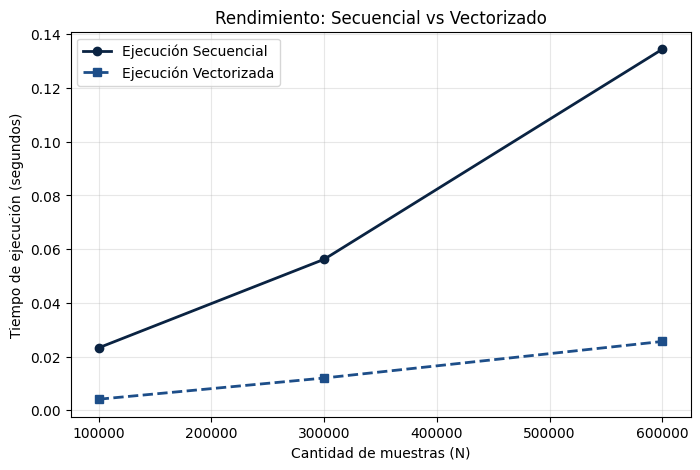

In [1]:
import time
import math
import numpy as np
import matplotlib.pyplot as plt

# 1.a) Medición secuencial (bucle Python)
def f_scalar(n):
    s = 0.0
    for i in range(1, n + 1):
        s += math.sqrt(i) + math.log(1 + i)
    return s

# 1.b) Versión vectorizada con numpy
def f_vector(n):
    a = np.arange(1, n + 1)
    return np.sqrt(a).sum() + np.log(1 + a).sum()

def main_ejercicio_1():
    tamanos_n = [100_000, 300_000, 600_000]
    tiempos_sec = []
    tiempos_vec = []

    print("n\t\tT_secuencial\tT_vectorizado\tSpeedup (S)")
    print("-" * 60)

    for n in tamanos_n:
        # Tiempo secuencial
        t0 = time.perf_counter()
        f_scalar(n)
        ts = time.perf_counter() - t0
        tiempos_sec.append(ts)

        # Tiempo vectorizado
        t0 = time.perf_counter()
        f_vector(n)
        tv = time.perf_counter() - t0
        tiempos_vec.append(tv)

        # Speedup
        speedup = ts / tv
        print(f"{n:,}\t{ts:.4f}s\t\t{tv:.4f}s\t\t{speedup:.2f}x")

    # --- Generación del Gráfico ---
    plt.figure(figsize=(8, 5))
    plt.plot(tamanos_n, tiempos_sec, marker='o', color='#0A2342', label='Ejecución Secuencial', linewidth=2)
    plt.plot(tamanos_n, tiempos_vec, marker='s', color='#1D4E89', label='Ejecución Vectorizada', linewidth=2, linestyle='--')
    plt.title('Rendimiento: Secuencial vs Vectorizado')
    plt.xlabel('Cantidad de muestras (N)')
    plt.ylabel('Tiempo de ejecución (segundos)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

if __name__ == '__main__':
    main_ejercicio_1()

¿Por qué la vectorización puede producir "speedup" sin paralelismo?

  

La vectorización produce un speedup significativo sin requerir múltiples hilos o procesos porque delega las operaciones a bibliotecas subyacentes escritas en lenguajes de bajo nivel (como C) altamente optimizadas. Además, aprovecha instrucciones de hardware especializadas en la CPU (como SIMD - Single Instruction, Multiple Data), permitiendo procesar bloques de memoria contiguos en un solo ciclo de reloj y eliminando la sobrecarga (overhead) que genera el intérprete de Python al evaluar el bucle elemento por elemento.

Ejercicio 2: Paralelismo práctico y limitaciones
Este ejercicio ejecuta las tareas IO-bound (con hilos) y CPU-bound (con procesos), recopila los resultados y genera dos gráficos de barras (uno al lado del otro) para visualizar el impacto del overhead.

--- 2.a) Resultados IO-bound (Hilos) ---
Hilos: 1	Tiempo: 2.0102s	Speedup: 1.00x	Eficiencia: 1.00
Hilos: 2	Tiempo: 1.0065s	Speedup: 2.01x	Eficiencia: 1.00
Hilos: 4	Tiempo: 0.5254s	Speedup: 3.84x	Eficiencia: 0.96
Hilos: 8	Tiempo: 0.2605s	Speedup: 7.75x	Eficiencia: 0.97

--- 2.b) Resultados CPU-bound (Procesos) ---
Procesos: 1	Tiempo: 0.2880s	Speedup: 1.11x	Eficiencia: 1.11
Procesos: 2	Tiempo: 0.2609s	Speedup: 1.22x	Eficiencia: 0.61
Procesos: 4	Tiempo: 0.3468s	Speedup: 0.92x	Eficiencia: 0.23


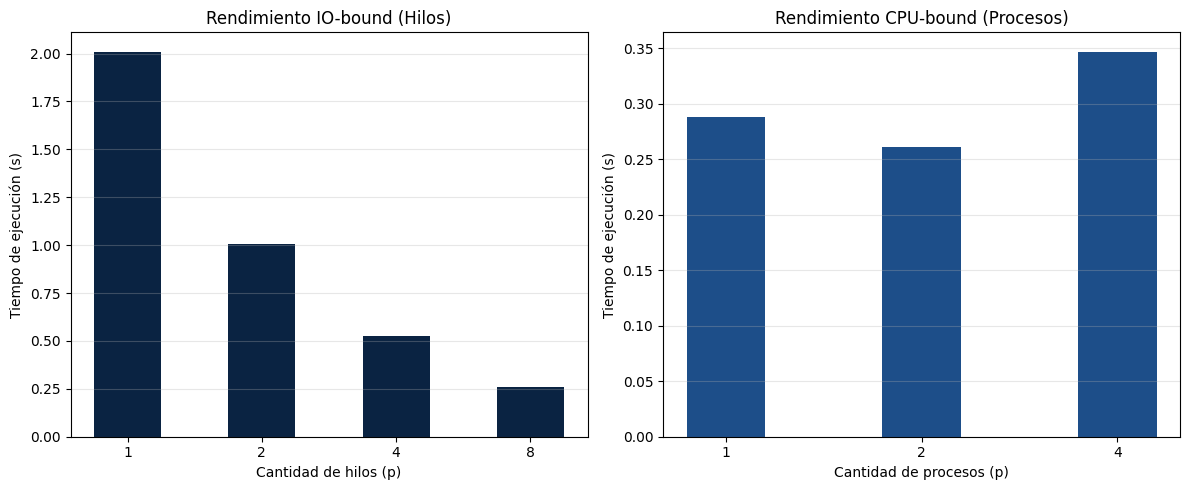

In [2]:
import time
from concurrent.futures import ThreadPoolExecutor
from multiprocessing import Pool
import matplotlib.pyplot as plt

# 2.a) Tarea IO-bound
def tarea_io(i):
    time.sleep(0.05)
    return i * 1

def medir_threads(p=4):
    datos = list(range(40))
    t0 = time.perf_counter()
    with ThreadPoolExecutor(max_workers=p) as ex:
        list(ex.map(tarea_io, datos))
    return time.perf_counter() - t0

# 2.b) Tarea CPU-bound
def trabajo_cpu(x):
    s = 0.0
    for i in range(200_000):
        s += (i % (x + 1)) * 0.00001
    return s

def medir_procesos(p=2):
    entradas = list(range(8))
    t0 = time.perf_counter()
    with Pool(processes=p) as pool:
        pool.map(trabajo_cpu, entradas)
    return time.perf_counter() - t0

def main_ejercicio_2():
    # Recopilar datos IO-bound
    print("--- 2.a) Resultados IO-bound (Hilos) ---")
    hilos_list = [1, 2, 4, 8]
    tiempos_io = []
    t_sec_io = medir_threads(1)

    for p in hilos_list:
        tp = medir_threads(p)
        tiempos_io.append(tp)
        s = t_sec_io / tp
        print(f"Hilos: {p}\tTiempo: {tp:.4f}s\tSpeedup: {s:.2f}x\tEficiencia: {(s/p):.2f}")

    # Recopilar datos CPU-bound
    print("\n--- 2.b) Resultados CPU-bound (Procesos) ---")
    procesos_list = [1, 2, 4]
    tiempos_cpu = []
    t_sec_cpu = medir_procesos(1)

    for p in procesos_list:
        tp = medir_procesos(p)
        tiempos_cpu.append(tp)
        s = t_sec_cpu / tp
        print(f"Procesos: {p}\tTiempo: {tp:.4f}s\tSpeedup: {s:.2f}x\tEficiencia: {(s/p):.2f}")

    # --- Generación de los Gráficos ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Gráfico IO-bound
    axes[0].bar([str(h) for h in hilos_list], tiempos_io, color='#0A2342', width=0.5)
    axes[0].set_title('Rendimiento IO-bound (Hilos)')
    axes[0].set_xlabel('Cantidad de hilos (p)')
    axes[0].set_ylabel('Tiempo de ejecución (s)')
    axes[0].grid(True, axis='y', alpha=0.3)

    # Gráfico CPU-bound
    axes[1].bar([str(p) for p in procesos_list], tiempos_cpu, color='#1D4E89', width=0.4)
    axes[1].set_title('Rendimiento CPU-bound (Procesos)')
    axes[1].set_xlabel('Cantidad de procesos (p)')
    axes[1].set_ylabel('Tiempo de ejecución (s)')
    axes[1].grid(True, axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    main_ejercicio_2()

El comportamiento observado concuerda con la Ley de Amdahl. Para las tareas IO-bound, el speedup es casi lineal porque la CPU pasa la mayor parte del tiempo inactiva esperando y el overhead es mínimo. Sin embargo, en el escenario CPU-bound, la eficiencia disminuye a medida que aumentamos la cantidad de procesos ($p$). Esto ocurre debido al costo de sincronización, la creación de procesos en memoria separada (IPC) y la fracción secuencial inevitable del programa, lo cual limita el speedup máximo teórico sin importar cuántos núcleos agreguemos.

Ejercicio 3: Decisión estratégica
Simula el procesamiento por lotes. Para hacer el gráfico más informativo e ilustrar la escalabilidad, se evalúa el secuencial (1 proceso) frente al paralelo con 2 y 4 procesos, y finalmente se grafica mediante un diagrama de barras.

--- 3.a) y 3.b) Procesamiento por Lotes ---
p	Tiempo		Speedup		Eficiencia
-------------------------------------------------------
1	0.2141s	1.03x		1.03
2	0.2550s	0.87x		0.43
4	0.2885s	0.76x		0.19


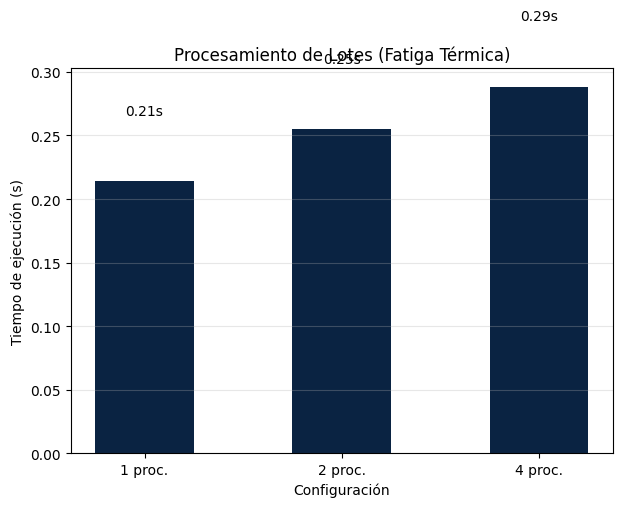

In [3]:
import time
import random
from concurrent.futures import ProcessPoolExecutor
import matplotlib.pyplot as plt

def procesar_lote(seed):
    random.seed(seed)
    data = [random.random() for _ in range(80_000)]
    s = sum(x**2 for x in data)
    return s

def medir_procesal(lotes, p=1):
    t0 = time.perf_counter()
    if p == 1:
        # Ejecución estrictamente secuencial
        for l in lotes:
            procesar_lote(l)
    else:
        # Ejecución paralela
        with ProcessPoolExecutor(max_workers=p) as ex:
            list(ex.map(procesar_lote, lotes))
    return time.perf_counter() - t0

def main_ejercicio_3():
    lotes = list(range(8))
    procesos_test = [1, 2, 4]
    tiempos_lotes = []

    print("--- 3.a) y 3.b) Procesamiento por Lotes ---")
    print("p\tTiempo\t\tSpeedup\t\tEficiencia")
    print("-" * 55)

    # Medir secuencial para base del speedup
    ts = medir_procesal(lotes, p=1)

    for p in procesos_test:
        tp = medir_procesal(lotes, p=p)
        tiempos_lotes.append(tp)
        speedup = ts / tp
        eficiencia = speedup / p
        print(f"{p}\t{tp:.4f}s\t{speedup:.2f}x\t\t{eficiencia:.2f}")

    # --- Generación del Gráfico ---
    plt.figure(figsize=(7, 5))
    barras = plt.bar([f"{p} proc." for p in procesos_test], tiempos_lotes, color='#0A2342', width=0.5)

    # Añadir el tiempo arriba de cada barra
    for barra in barras:
        yval = barra.get_height()
        plt.text(barra.get_x() + barra.get_width()/2, yval + 0.05, f'{yval:.2f}s', ha='center', va='bottom')

    plt.title('Procesamiento de Lotes (Fatiga Térmica)')
    plt.xlabel('Configuración')
    plt.ylabel('Tiempo de ejecución (s)')
    plt.grid(True, axis='y', alpha=0.3)
    plt.show()

if __name__ == '__main__':
    main_ejercicio_3()

Basado en los resultados obtenidos para $p=4$, donde observamos un speedup $S > 1$ pero una eficiencia $E < 1$, la recomendación técnica es escalar verticalmente utilizando un pool local de procesos si el tamaño de la carga de trabajo es moderada y cabe dentro de una sola máquina de alto rendimiento. Debido a que los lotes son completamente independientes (es un problema inherentemente paralelo), no existe necesidad de sincronización interna que afecte el resultado algorítmico, y la complejidad por unidad es suficientemente alta para compensar la sobrecarga de coordinación local. Sin embargo, permanecer secuencial es ineficiente dada la intensidad de cálculo. Por otro lado, escalar horizontalmente (distribución en clúster) se justifica únicamente si el volumen de datos por lote crece tanto que agota la RAM local, ya que la comunicación a través de la red generaría costos y cuellos de botella adicionales (costo de red > costo IPC).

Reflexión Diagnóstica Final:  Para decidir si paralelizar una aplicación de ciencia de datos, utilizaría un enfoque dual que evalúe métricas tanto cuantitativas como cualitativas. A nivel cuantitativo, el criterio principal es la medición empírica del speedup y la eficiencia bajo distintos niveles de carga (escalabilidad fuerte y débil). Si al añadir recursos computacionales el speedup se estanca rápidamente (baja eficiencia según la Ley de Amdahl), el cuello de botella se encuentra en la fracción secuencial o en el overhead de coordinación, sugiriendo que la paralelización por procesos podría no ser rentable computacionalmente.Cualitativamente, evaluaría primero la arquitectura del problema. Si las tareas requieren una alta transferencia de estado o comunicación constante entre trabajadores, los costos de sincronización arruinarán el desempeño global. En estos casos, el primer paso siempre debería ser agotar las posibilidades de vectorización. Como vimos en el Ejercicio 1, la optimización a nivel de hardware (SIMD vía numpy) puede brindar un speedup dramático (a menudo de $10x$ a $50x$) sin la complejidad arquitectónica de instanciar y coordinar procesos paralelos.En conclusión, la regla a seguir en aplicaciones de ciencia de datos debería ser: optimizar algorítmicamente primero (vectorización), paralelizar a nivel de hardware (multiprocesamiento/hilos) para tareas inherentemente independientes, y distribuir computacionalmente (clusters) sólo cuando el tamaño de los datos exceda definitivamente las capacidades verticales de un solo nodo de procesamiento.